In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# ---Notebook configuration---------------------------------------------------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")


# ---Project paths------------------------------------------------------------
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

DEV_DATA_PATH = PROCESSED_DATA_DIR / "dev_modeling_dataset.parquet"
HOLDOUT_TRANSACTION_PATH = PROCESSED_DATA_DIR / "test_transaction_holdout.parquet"
HOLDOUT_IDENTITY_PATH = PROCESSED_DATA_DIR / "test_identity_holdout.parquet"

FINAL_MODEL_PATH = MODELS_DIR / "final_lightgbm_pipeline.joblib"
FINAL_MODEL_METADATA_PATH = MODELS_DIR / "final_lightgbm_metadata.json"

HOLDOUT_SCORED_PATH = PROCESSED_DATA_DIR / "holdout_scored.parquet"
HOLDOUT_METRICS_PATH = PROCESSED_DATA_DIR / "holdout_metrics.csv"
THRESHOLD_RESULTS_PATH = PROCESSED_DATA_DIR / "holdout_threshold_analysis.csv"

# ---Load final fitted pipeline-----------------------------------------------
final_model = joblib.load(FINAL_MODEL_PATH)

print("Final model loaded successfully.")
print("Model path:", FINAL_MODEL_PATH.resolve())
print()

# ---Load model metadata------------------------------------------------------
with open(FINAL_MODEL_METADATA_PATH, "r", encoding="utf-8") as file:
    final_model_metadata = json.load(file)

print("Model metadata loaded successfully.")
print()

# ---Load development modeling dataset for schema reference--------------------
dev_model_df = pd.read_parquet(DEV_DATA_PATH)

target_col = "isFraud"
expected_feature_columns = [col for col in dev_model_df.columns if col != target_col]

print("Development modeling dataset loaded successfully.")
print("Reference development shape:", dev_model_df.shape)
print("Expected feature count:", len(expected_feature_columns))
print()


# ---Load raw holdout transaction and identity datasets------------------------
holdout_transaction_df = pd.read_parquet(HOLDOUT_TRANSACTION_PATH)
holdout_identity_df = pd.read_parquet(HOLDOUT_IDENTITY_PATH)

print("Holdout transaction shape:", holdout_transaction_df.shape)
print("Holdout identity shape:", holdout_identity_df.shape)
print()

# ---Merge holdout datasets---------------------------------------------------
join_key = "TransactionID"

holdout_df = holdout_transaction_df.merge(
    holdout_identity_df,
    on=join_key,
    how="left",
)

print("Merged holdout dataset shape:", holdout_df.shape)
print()

# ---Basic holdout checks-----------------------------------------------------
print("Holdout target distribution:")
print(holdout_df[target_col].value_counts(normalize=True))
print()


Final model loaded successfully.
Model path: C:\Users\zeina\Models\final_lightgbm_pipeline.joblib

Model metadata loaded successfully.

Development modeling dataset loaded successfully.
Reference development shape: (472432, 464)
Expected feature count: 463

Holdout transaction shape: (118108, 394)
Holdout identity shape: (23769, 41)

Merged holdout dataset shape: (118108, 434)

Holdout target distribution:
isFraud
0   0.9656
1   0.0344
Name: proportion, dtype: float64



# Recreate Feature Engineering on Holdout Data

In [2]:
# ---Working copy-------------------------------------------------------------
holdout_model_df = holdout_df.copy()

# ---Transaction amount features----------------------------------------------
holdout_model_df["TransactionAmt_log1p"] = np.log1p(holdout_model_df["TransactionAmt"])
holdout_model_df["TransactionAmt_is_small"] = (holdout_model_df["TransactionAmt"] < 5).astype(int)
holdout_model_df["TransactionAmt_is_large"] = (holdout_model_df["TransactionAmt"] > 500).astype(int)

# ---Time features------------------------------------------------------------
seconds_in_day = 24 * 60 * 60
seconds_in_week = 7 * seconds_in_day

holdout_model_df["TransactionHour"] = (holdout_model_df["TransactionDT"] // 3600) % 24
holdout_model_df["TransactionDay"] = holdout_model_df["TransactionDT"] // seconds_in_day
holdout_model_df["TransactionWeek"] = holdout_model_df["TransactionDT"] // seconds_in_week

holdout_model_df["TransactionHour_sin"] = np.sin(
    2 * np.pi * holdout_model_df["TransactionHour"] / 24
)
holdout_model_df["TransactionHour_cos"] = np.cos(
    2 * np.pi * holdout_model_df["TransactionHour"] / 24
)

# ---Email domain features----------------------------------------------------
holdout_model_df["P_email_provider"] = holdout_model_df["P_emaildomain"].str.split(".").str[0]
holdout_model_df["R_email_provider"] = holdout_model_df["R_emaildomain"].str.split(".").str[0]

holdout_model_df["P_email_suffix"] = holdout_model_df["P_emaildomain"].str.split(".").str[-1]
holdout_model_df["R_email_suffix"] = holdout_model_df["R_emaildomain"].str.split(".").str[-1]

holdout_model_df["email_domain_match"] = (
    holdout_model_df["P_emaildomain"] == holdout_model_df["R_emaildomain"]
).astype(int)

holdout_model_df["email_suffix_match"] = (
    holdout_model_df["P_email_suffix"] == holdout_model_df["R_email_suffix"]
).astype(int)

holdout_model_df["P_emaildomain_missing"] = holdout_model_df["P_emaildomain"].isnull().astype(int)
holdout_model_df["R_emaildomain_missing"] = holdout_model_df["R_emaildomain"].isnull().astype(int)

holdout_model_df["both_email_missing"] = (
    holdout_model_df["P_emaildomain"].isnull() & holdout_model_df["R_emaildomain"].isnull()
).astype(int)

holdout_model_df["both_email_present"] = (
    holdout_model_df["P_emaildomain"].notnull() & holdout_model_df["R_emaildomain"].notnull()
).astype(int)

# ---Selected missingness indicators------------------------------------------
missing_indicator_columns = [
    col for col in expected_feature_columns
    if col.endswith("_missing") and col not in ["P_emaildomain_missing", "R_emaildomain_missing"]
]

base_missing_columns = [
    col.replace("_missing", "") for col in missing_indicator_columns
]

for base_col, indicator_col in zip(base_missing_columns, missing_indicator_columns):
    if base_col in holdout_model_df.columns:
        holdout_model_df[indicator_col] = holdout_model_df[base_col].isnull().astype(int)
    else:
        holdout_model_df[indicator_col] = 1

print("Feature engineering on holdout dataset completed.")
print("Missing indicators recreated:", len(missing_indicator_columns))
print()


Feature engineering on holdout dataset completed.
Missing indicators recreated: 15



# Align Holdout Dataset to Training Schema & Evaluation

Holdout feature matrix aligned to training schema.
Holdout feature shape: (118108, 463)
Missing expected columns added: 0
Extra columns removed: 0



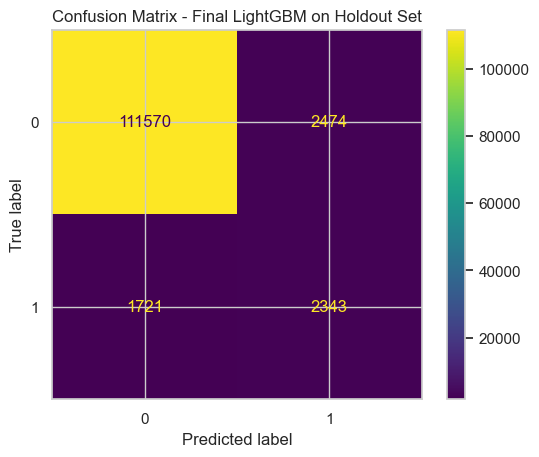

<Figure size 800x600 with 0 Axes>

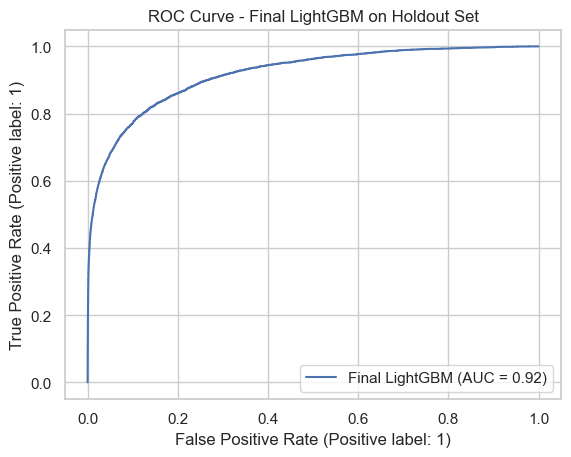

<Figure size 800x600 with 0 Axes>

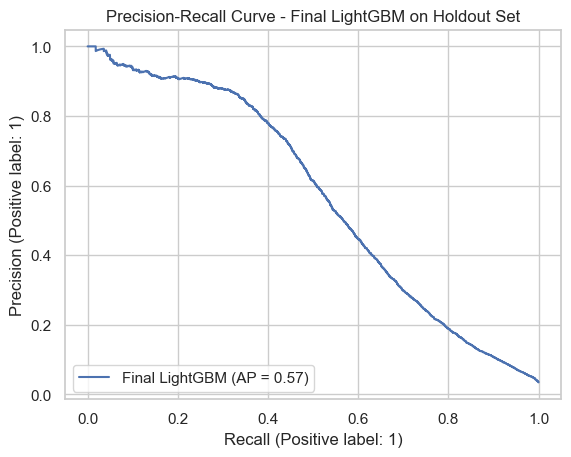

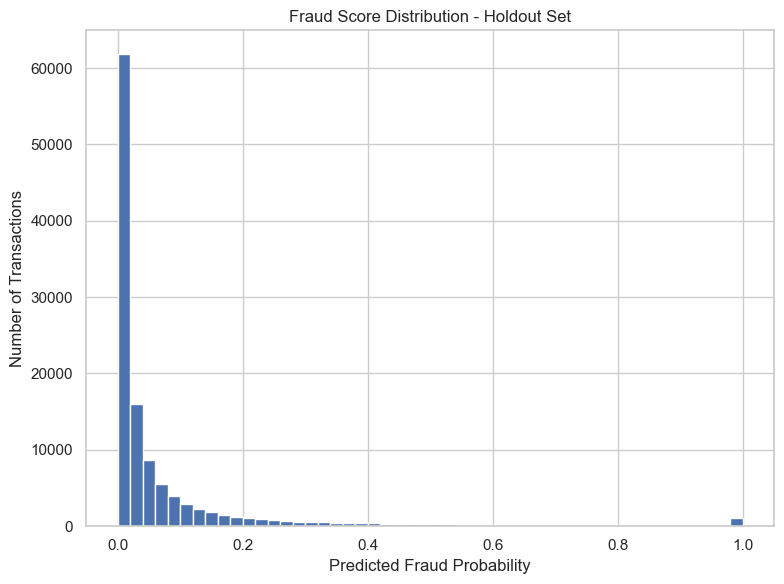

In [3]:
# ---Remove columns excluded from modeling------------------------------------
drop_if_present = ["TransactionID", "TransactionDT"]

for col in drop_if_present:
    if col in holdout_model_df.columns:
        holdout_model_df.drop(columns=col, inplace=True)

# ---Separate holdout features and target-------------------------------------
y_holdout = holdout_model_df[target_col].copy()
X_holdout = holdout_model_df.drop(columns=[target_col]).copy()

# ---Add any expected columns missing from holdout-----------------------------
missing_feature_columns = [
    col for col in expected_feature_columns
    if col not in X_holdout.columns
]

for col in missing_feature_columns:
    X_holdout[col] = np.nan

# ---Restrict and order columns to match training schema----------------------
extra_feature_columns = [
    col for col in X_holdout.columns
    if col not in expected_feature_columns
]

if extra_feature_columns:
    X_holdout.drop(columns=extra_feature_columns, inplace=True)

X_holdout = X_holdout[expected_feature_columns].copy()

print("Holdout feature matrix aligned to training schema.")
print("Holdout feature shape:", X_holdout.shape)
print("Missing expected columns added:", len(missing_feature_columns))
print("Extra columns removed:", len(extra_feature_columns))
print()

# ---Generate holdout predictions---------------------------------------------
holdout_pred_proba = final_model.predict_proba(X_holdout)[:, 1]
holdout_pred = (holdout_pred_proba >= 0.5).astype(int)

# ---Compute core metrics-----------------------------------------------------
holdout_metrics = pd.DataFrame({
    "dataset": ["Holdout"],
    "model": ["Final LightGBM"],
    "roc_auc": [roc_auc_score(y_holdout, holdout_pred_proba)],
    "pr_auc": [average_precision_score(y_holdout, holdout_pred_proba)],
    "precision_at_0_50": [precision_score(y_holdout, holdout_pred, zero_division=0)],
    "recall_at_0_50": [recall_score(y_holdout, holdout_pred, zero_division=0)],
    "f1_at_0_50": [f1_score(y_holdout, holdout_pred, zero_division=0)],
})

holdout_metrics

# ---Confusion matrix---------------------------------------------------------
holdout_cm = confusion_matrix(y_holdout, holdout_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=holdout_cm)
disp.plot()

plt.title("Confusion Matrix - Final LightGBM on Holdout Set")
plt.show()

# ---ROC curve----------------------------------------------------------------
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_holdout,
    holdout_pred_proba,
    name="Final LightGBM",
)
plt.title("ROC Curve - Final LightGBM on Holdout Set")
plt.show()

# ---Precision-recall curve---------------------------------------------------
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_holdout,
    holdout_pred_proba,
    name="Final LightGBM",
)
plt.title("Precision-Recall Curve - Final LightGBM on Holdout Set")
plt.show()

# ---Fraud score distribution-------------------------------------------------
plt.figure(figsize=(8, 6))
plt.hist(holdout_pred_proba, bins=50)
plt.title("Fraud Score Distribution - Holdout Set")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# Threshold Analysis

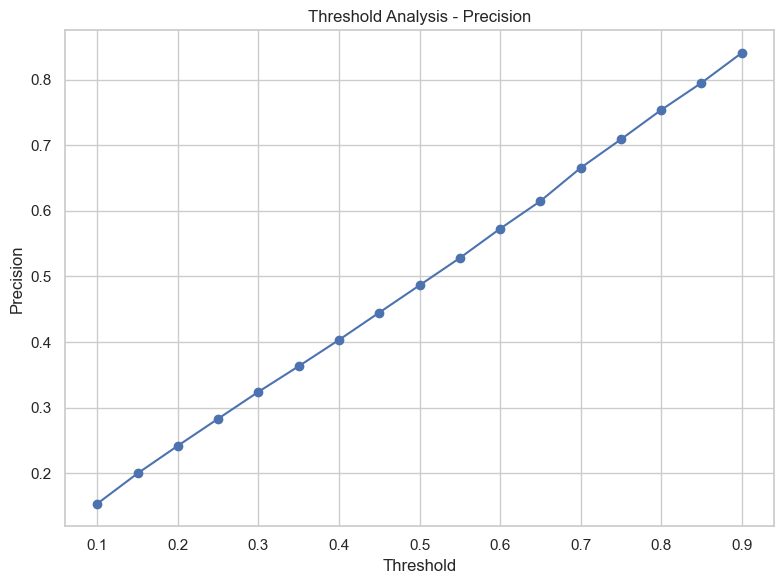

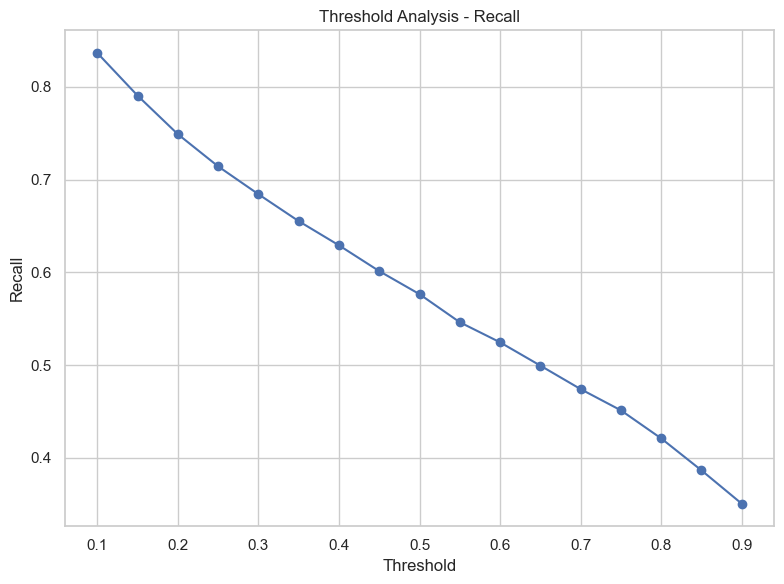

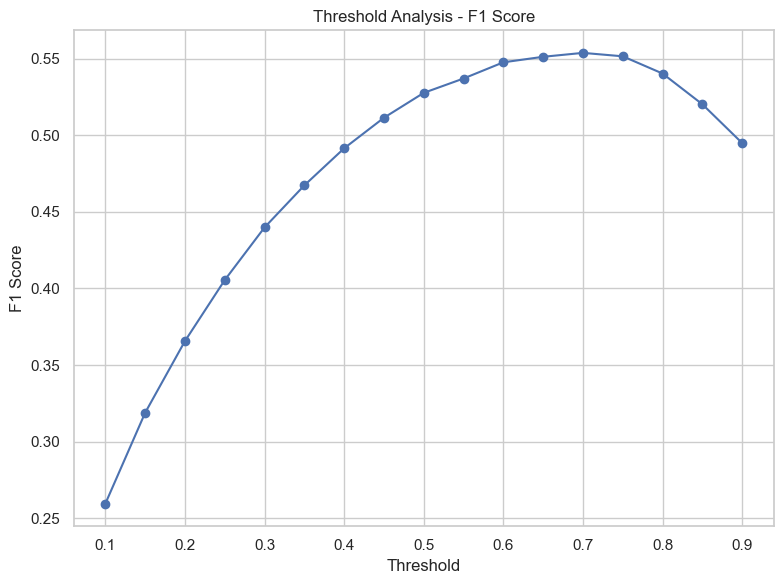

In [4]:
# ---Evaluate multiple decision thresholds------------------------------------
threshold_grid = np.round(np.arange(0.10, 0.91, 0.05), 2)

threshold_results = []

for threshold in threshold_grid:
    threshold_pred = (holdout_pred_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_holdout, threshold_pred).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_holdout, threshold_pred, zero_division=0),
        "recall": recall_score(y_holdout, threshold_pred, zero_division=0),
        "f1": f1_score(y_holdout, threshold_pred, zero_division=0),
        "predicted_fraud_rate": threshold_pred.mean(),
        "transactions_flagged": int(threshold_pred.sum()),
        "true_fraud_captured": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df


# ---Threshold comparison plot: precision-------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], marker="o")
plt.title("Threshold Analysis - Precision")
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

# ---Threshold comparison plot: recall----------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], marker="o")
plt.title("Threshold Analysis - Recall")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.tight_layout()
plt.show()

# ---Threshold comparison plot: F1--------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1"], marker="o")
plt.title("Threshold Analysis - F1 Score")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()


# Fraud Decision Policy Simulation

In [5]:
# ---Define operational score bands-------------------------------------------
approve_threshold = 0.20
decline_threshold = 0.60

# ---Assign operational actions-----------------------------------------------
holdout_scored_df = X_holdout.copy()
holdout_scored_df["actual_isFraud"] = y_holdout.values
holdout_scored_df["fraud_score"] = holdout_pred_proba

holdout_scored_df["recommended_action"] = np.select(
    condlist=[
        holdout_scored_df["fraud_score"] < approve_threshold,
        holdout_scored_df["fraud_score"] < decline_threshold,
        holdout_scored_df["fraud_score"] >= decline_threshold,
    ],
    choicelist=[
        "Approve",
        "Manual Review",
        "Decline",
    ],
    default="Manual Review",
)

# ---Summarize operational policy---------------------------------------------
policy_summary = (
    holdout_scored_df
    .groupby("recommended_action")
    .agg(
        transactions=("actual_isFraud", "size"),
        fraud_cases=("actual_isFraud", "sum"),
        fraud_rate=("actual_isFraud", "mean"),
        min_score=("fraud_score", "min"),
        max_score=("fraud_score", "max"),
    )
    .reset_index()
    .sort_values("recommended_action")
)

policy_summary


,recommended_action,transactions,fraud_cases,fraud_rate,min_score,max_score
0,Approve,105522,1020,0.0097,0.0000,0.2000
1,Decline,3723,2132,0.5727,0.6002,1.0000
2,Manual Review,8863,912,0.1029,0.2000,0.5997


# Final Holdout Summary

In [6]:
# ---Create concise project-level summary-------------------------------------
final_holdout_summary = pd.DataFrame({
    "model": ["Final LightGBM"],
    "evaluation_dataset": ["Holdout"],
    "holdout_rows": [len(X_holdout)],
    "holdout_fraud_rate": [y_holdout.mean()],
    "roc_auc": [holdout_metrics.loc[0, "roc_auc"]],
    "pr_auc": [holdout_metrics.loc[0, "pr_auc"]],
    "precision_at_0_50": [holdout_metrics.loc[0, "precision_at_0_50"]],
    "recall_at_0_50": [holdout_metrics.loc[0, "recall_at_0_50"]],
    "f1_at_0_50": [holdout_metrics.loc[0, "f1_at_0_50"]],
    "approve_threshold": [approve_threshold],
    "decline_threshold": [decline_threshold],
})

final_holdout_summary

# ---Save scored holdout data-------------------------------------------------
holdout_scored_df.to_parquet(HOLDOUT_SCORED_PATH, index=False)

# ---Save evaluation tables---------------------------------------------------
holdout_metrics.to_csv(HOLDOUT_METRICS_PATH, index=False)
threshold_results_df.to_csv(THRESHOLD_RESULTS_PATH, index=False)

print("Holdout scored dataset saved to:", HOLDOUT_SCORED_PATH.resolve())
print("Holdout metrics saved to:", HOLDOUT_METRICS_PATH.resolve())
print("Threshold analysis saved to:", THRESHOLD_RESULTS_PATH.resolve())
print()

Holdout scored dataset saved to: C:\Users\zeina\data\processed\holdout_scored.parquet
Holdout metrics saved to: C:\Users\zeina\data\processed\holdout_metrics.csv
Threshold analysis saved to: C:\Users\zeina\data\processed\holdout_threshold_analysis.csv



## Conclusion

This notebook completed the final evaluation of the fraud detection model using the untouched holdout dataset representing future transactions. The tuned LightGBM model maintained strong predictive performance on this out-of-time data, confirming that the patterns learned during development generalize beyond the training period.

The model was evaluated not only as a binary classifier but as a **fraud risk scoring system**. Based on the predicted fraud probabilities, a three-level operational policy was simulated:

- **Approve (< 0.20)** for low-risk transactions  
- **Manual Review (0.20–0.60)** for medium-risk transactions  
- **Decline (≥ 0.60)** for high-risk transactions  

The resulting segmentation shows clear separation between low-risk and high-risk transactions, with the highest-risk segment containing a high concentration of fraud cases. This demonstrates that the model can effectively prioritize suspicious transactions and support operational fraud investigation workflows.

Overall, the project produced a complete machine learning pipeline for fraud risk detection, including structured data preparation, feature engineering, model comparison, hyperparameter tuning, final model training, and out-of-time evaluation. The final model functions as a probabilistic fraud scoring engine that can support automated transaction decisions and risk-based investigation strategies.